# Part 4 Task
## Graph Recreation

This notebook contains mostly explanations and useful examples for the modules `time`, `datetime` and `dateutil`.
There are a few exercises for you to make sure that you understand the concepts.

**Table of Content**
1. [Preparing the data](#sec1)
2. [Graph 1: total pageviews per show](#sec2)
3. [Graph 2: aligned pageview trajectories per show](#sec3)

<h1 id="sec1">Preparing the data</h1>

<h3>Import requirements</h3>

In [135]:
import mwclient
from mwclient import Site
from mwviews.api import PageviewsClient
from time import mktime
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import random

<h3>Collect the pageview data from the selected shows</h3>

In [8]:
show_names = [
    "The Glory (TV series)", "Moving (South Korean TV series)", "My Demon", 
    "King the Land", "Gyeongseong Creature", "Twinkling Watermelon",
    "Death's Game", "Crash Course in Romance", "Welcome to Samdal-ri",
    "Celebrity (South Korean TV series)", "A Time Called You", "Perfect Marriage Revenge",
    "See You in My 19th Life", "The Good Bad Mother", "My Lovely Liar",
    "Doona!", "Love to Hate You (TV series)", "Daily Dose of Sunshine",
    "Destined with You"
]

In [66]:
p = PageviewsClient(user_agent="CS 315 student (nh107)")
data = p.article_views('en.wikipedia', show_names, 
                       start='20220601', end='20240601')

In [67]:
pageviews_df = pd.DataFrame(data)

pageviews_df

,2022-06-01,2022-06-02,2022-06-03,2022-06-04,2022-06-05,2022-06-06,2022-06-07,2022-06-08,2022-06-09,2022-06-10,...,2024-05-23,2024-05-24,2024-05-25,2024-05-26,2024-05-27,2024-05-28,2024-05-29,2024-05-30,2024-05-31,2024-06-01
Destined_with_You,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5,4,5,5,5,6,5,6,5,7
Love_to_Hate_You_(TV_series),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,237.0,103.0,...,414,403,431,458,426,423,399,406,376,372
Crash_Course_in_Romance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,582,567,640,696,738,715,638,639,642,586
The_Glory_(TV_series),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2493,2680,2699,2951,2878,2761,2638,2500,2608,2614
The_Good_Bad_Mother,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,535,601,655,618,558,540,637,578,576,499
See_You_in_My_19th_Life,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,639,666,812,736,724,699,612,684,689,664
King_the_Land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,995,1004,1026,1250,1255,1195,1129,1182,1064,1049
Celebrity_(South_Korean_TV_series),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,748,739,768,792,713,732,757,691,666,702
My_Lovely_Liar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,559,505,557,573,554,624,562,516,845,553
Moving_(South_Korean_TV_series),199.0,176.0,183.0,167.0,212.0,166.0,187.0,205.0,197.0,159.0,...,1424,1314,1441,1858,1643,1756,1551,1656,1866,1778


<h1 id="sec2">Graph 1: total pageviews per show</h1>

<p>This graph is a horizontal bar chart of aggregate pageviews from 2022-06-01 to 2024-06-01 for each show.</p>

<h3>Get aggregate pageviews for each show</h3>

In [68]:
pageviews_df["pageviews_sum"] = pageviews_df.sum(axis=1)

pageviews_sum_df = pageviews_df[["pageviews_sum"]].reset_index()
pageviews_sum_df = pageviews_sum_df.sort_values("pageviews_sum")

In [69]:
pageviews_sum_df

,index,pageviews_sum
0,Destined_with_You,1156.0
12,Daily_Dose_of_Sunshine,559765.0
1,Love_to_Hate_You_(TV_series),822729.0
11,Doona!,1033094.0
8,My_Lovely_Liar,1169482.0
4,The_Good_Bad_Mother,1172570.0
5,See_You_in_My_19th_Life,1247697.0
14,Perfect_Marriage_Revenge,1266164.0
10,A_Time_Called_You,1349860.0
7,Celebrity_(South_Korean_TV_series),1441608.0


<h3>Plot graph</h3>

(0.0, 5980838.600000001)

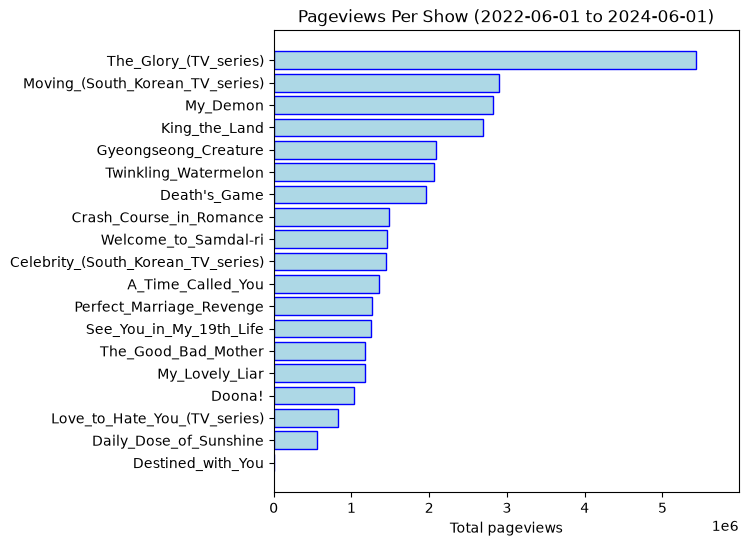

In [70]:
fig, ax = plt.subplots(figsize=(6, 6))

#create  a horizontal bar graph
ax.barh(
    pageviews_sum_df['index'], 
    width=pageviews_sum_df['pageviews_sum'],
    color="lightblue",
    edgecolor="blue",
    )
ax.set_title('Pageviews Per Show (2022-06-01 to 2024-06-01)')
ax.set_xlabel("Total pageviews")
ax.yaxis.tick_left()

#get the highest value for pageviews_sum for the x axis scaling (idk if this is necessary)
max_pageviews = pageviews_sum_df["pageviews_sum"].max()
#leave space at the end 
plt.xlim(0, max_pageviews * 1.10)

<h1 id="sec3">Graph 2: aligned pageview trajectories per show</h1>

<p>This graph is a series of line charts which show the pageviews of a show before and after its peak date.</p>

<h3>Get the appropriate pageview days for each show</h3>

In [71]:
pageviews_df = pageviews_df.drop(columns=["pageviews_sum"])

In [72]:
pageviews_df["pageviews_max"] = pageviews_df.idxmax(axis=1)

pageviews_max_df = pageviews_df.sort_values("pageviews_max")

In [ ]:
pageviews_max_df["50_before"] = pageviews_max_df["pageviews_max"] - pd.Timedelta(days=50)
pageviews_max_df["50_after"] = pageviews_max_df["pageviews_max"] + pd.Timedelta(days=50)

In [74]:
pageviews_max_df

,2022-06-01 00:00:00,2022-06-02 00:00:00,2022-06-03 00:00:00,2022-06-04 00:00:00,2022-06-05 00:00:00,2022-06-06 00:00:00,2022-06-07 00:00:00,2022-06-08 00:00:00,2022-06-09 00:00:00,2022-06-10 00:00:00,...,2024-05-26 00:00:00,2024-05-27 00:00:00,2024-05-28 00:00:00,2024-05-29 00:00:00,2024-05-30 00:00:00,2024-05-31 00:00:00,2024-06-01 00:00:00,pageviews_max,50_before,50_after
Destined_with_You,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5,5,6,5,6,5,7,2023-01-17,2022-11-28,2023-03-08
Love_to_Hate_You_(TV_series),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,237.0,103.0,...,458,426,423,399,406,376,372,2023-02-11,2022-12-23,2023-04-02
Crash_Course_in_Romance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,696,738,715,638,639,642,586,2023-03-05,2023-01-14,2023-04-24
The_Glory_(TV_series),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2951,2878,2761,2638,2500,2608,2614,2023-03-12,2023-01-21,2023-05-01
The_Good_Bad_Mother,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,618,558,540,637,578,576,499,2023-06-09,2023-04-20,2023-07-29
See_You_in_My_19th_Life,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,736,724,699,612,684,689,664,2023-06-18,2023-04-29,2023-08-07
King_the_Land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1250,1255,1195,1129,1182,1064,1049,2023-06-18,2023-04-29,2023-08-07
Celebrity_(South_Korean_TV_series),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,792,713,732,757,691,666,702,2023-07-02,2023-05-13,2023-08-21
My_Lovely_Liar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,573,554,624,562,516,845,553,2023-08-09,2023-06-20,2023-09-28
Moving_(South_Korean_TV_series),199.0,176.0,183.0,167.0,212.0,166.0,187.0,205.0,197.0,159.0,...,1858,1643,1756,1551,1656,1866,1778,2023-08-17,2023-06-28,2023-10-06


In [ ]:
pageviews_max_df = pageviews_max_df.reset_index()

<h3>Plot graph</h3>

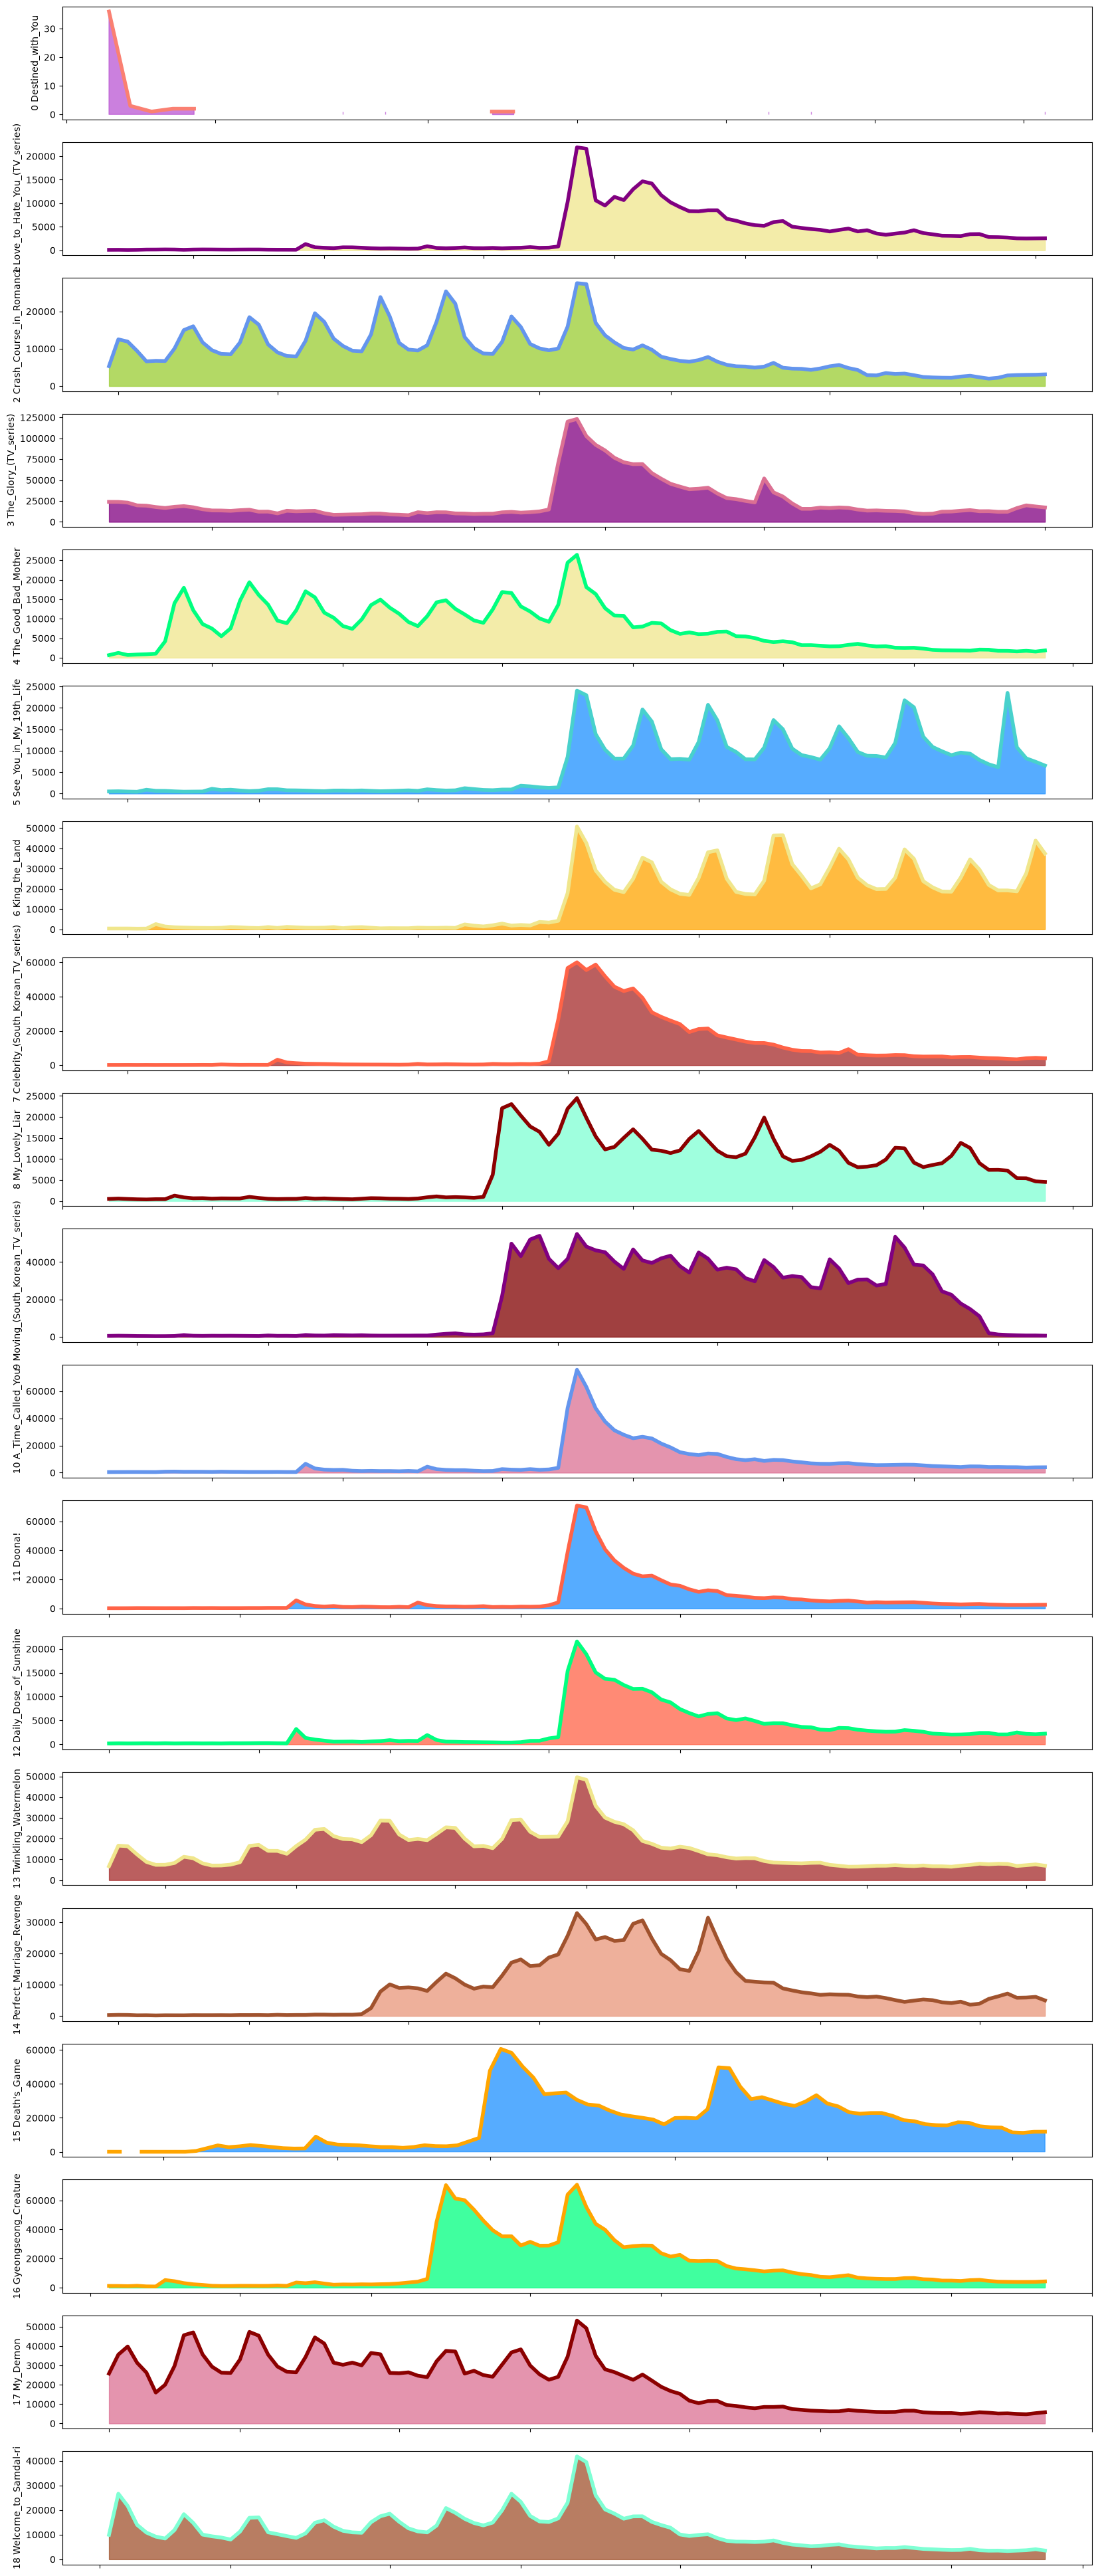

In [145]:
fig, ax = plt.subplots(nrows=19, ncols=1, figsize=(20, 50))

colors = [
    "aquamarine", "brown", "cornflowerblue", "darkolivegreen", "darksalmon", "deeppink", "dodgerblue",
    "darkseagreen", "orange", "silver", "yellowgreen", "salmon", "purple", "khaki", "darkred", "mediumturquoise",
    "tomato", "sienna", "palevioletred", "springgreen", "slategrey", "maroon", "hotpink", "mediumorchid", "powderblue"
]

for i in range(len(pageviews_max_df)):
    show = show_names[i]
    show_row = pageviews_max_df[pageviews_max_df["index"] == show]
    dates = show_row[["50_before", "50_after"]].values[0]
    start, end = dates[0], dates[1]

    #get the data for each show for desired range
    show_data = show_row.loc[:, start:end].iloc[0]
    
    #plot the data with a linechart
    line_color = random.choice(colors)
    ax[i].plot(show_data, color=line_color, linewidth=4)

    #fill the graph underneath
    fill_color = random.choice(colors)
    while fill_color == line_color:
        fill_color = random.choice(colors)
    ax[i].fill_between(show_data.index, show_data.values, 0, color=fill_color, alpha=0.75)

    ax[i].set_xticklabels([])
    ax[i].set_ylabel(f"{i} {show}")
    ax[i].yaxis.tick_left()